# Autoregressive Image Modeling

In [1]:
import os
import math
from sys import exit

import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf')  # set the figure format to svg

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import lightning as pl
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint, RichProgressBar
from lightning.pytorch.callbacks.progress.rich_progress import RichProgressBarTheme
from lightning.pytorch.loggers import TensorBoardLogger

import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../../data'
CHECKPOINT_DIR = 'checkpoints'

pl.seed_everything(42)

# set deterministic for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

Seed set to 42


device(type='cuda')

## Data Module

In [2]:
def discretize(imgs):
    return (imgs*255).long()  # [0, 1] -> [0, 255], float -> long

In [3]:
def show(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0., max=1.)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

In [4]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir=DATA_DIR, batch_size=32, num_workers=0):
        super().__init__()
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def prepare_data(self):
        datasets.MNIST(root=self.data_dir, train=True, download=True)
        datasets.MNIST(root=self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # multi gpus, load after prepare_data
        entire_dataset = datasets.MNIST(
            root=self.data_dir,
            train=True,
            transform=transforms.Compose(
                [
                    transforms.ToTensor(),
                    discretize
                ]
            ),
            download=False,
        )

        # show the first 8 images
        show(entire_dataset.data[:8].unsqueeze(1).float() / 255.0)

        self.train_dataset, self.val_dataset = data.random_split(
            entire_dataset, [55_000, 5_000]
        )

        self.test_dataset = datasets.MNIST(
            root=self.data_dir,
            train=False,
            transform=transforms.ToTensor(),
            download=False
        )

    def train_dataloader(self):
        return data.DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers  # uncomment this line if you are using cluster
        )

    def val_dataloader(self):
        return data.DataLoader(
            self.val_dataset,
            batch_size=self.batch_size // 8,
            shuffle=False,
            num_workers=self.num_workers,  # uncomment this line if you are using cluster
            # persistent_workers=True
        )

    def test_dataloader(self):
        return data.DataLoader(
            self.test_dataset,
            batch_size=self.batch_size // 8,
            shuffle=False,
            num_workers=self.num_workers  # uncomment this line if you are using cluster
        )

In [5]:
data_module = MNISTDataModule(
    data_dir=DATA_DIR,
    batch_size=256,
    num_workers=0  # set to positive value if you are using cluster
)

<Figure size 640x480 with 0 Axes>

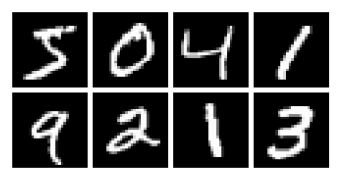

In [6]:
data_module.prepare_data()
data_module.setup()

train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()

## Masked Causal(Autoregressive) Convolutions

In [7]:
class MaskedCausalConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, mask, kwargs):
        """
        Convolution kernel with mask applied to the weights to ensure causality.
        :param in_channels: number of input channels
        :param out_channels: number of output channels
        :param mask: tensor of shape [kernel_size_H, kernel_size_W] with 0s for
                        weights that should be masked and 1s for weights that should
                        be kept.
        :param kwargs: additional arguments to pass to the convolution layer
        """
        super().__init__()
        kernel_size = (mask.size(0), mask.size(1))
        dilation = 1 if "dilation" not in kwargs else kwargs["dilation"]
        padding = tuple([dilation * (kernel_size[i] - 1) // 2 for i in range(2)])

        # define the convolution layer
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size, padding=padding, **kwargs
        )
        # mask as buffer to ensure it is moved to the same device as the model
        # and not treated as a model parameter
        self.register_buffer("mask", mask[None, None])

    def forward(self, x):
        self.conv.weight.data *= self.mask  # apply the mask
        return self.conv(x)

## Stacking Causal Convolutions

Here we stack multiple causal convolution layers to build the autoregressive model. To ensure there's no blind spot in the receptive field, we split the convolutional layers into two stacks: one for the vertical and one for the horizontal direction.

In [8]:
class CausalConvolutionVStack(MaskedCausalConvolution):
    def __init__(self, in_channels, out_channels, kernel_size=3, mask_center=False, **kwargs):
        """
        Vertical stack of causal convolution layers. The mask is applied to the weights to ensure causality,
        which is applied to mask out all pixels below the current pixel.
        :param in_channels: number of input channels
        :param out_channels: number of output channels
        :param kernel_size: size of the convolution kernel
        :param mask_center: for the first convolutional layer, mask the center pixel
        :param kwargs: other arguments to pass to the convolution layer
        """
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size // 2 + 1:, :] = 0

        # for the first layer, mask the center pixel
        if mask_center:
            mask[kernel_size // 2, :] = 0
        super().__init__(in_channels, out_channels, mask, kwargs)

In [9]:
class CausalConvolutionHStack(MaskedCausalConvolution):
    def __init__(self, in_channels, out_channels, kernel_size=3, mask_center=False, **kwargs):
        """
        Horizontal stack of causal convolution layers. The mask is applied to the weights to ensure causality,
        which is applied to mask out all pixels to the left of the current pixel.
        :param in_channels: number of input channels
        :param out_channels: number of output channels
        :param kernel_size: size of the convolution kernel, the kernel has a size of 1 in the vertical direction
            because we only care about the horizontal direction
        :param mask_center: for the first convolutional layer, mask the center pixel
        :param kwargs: other arguments to pass to the convolution layer
        """
        mask = torch.ones(1, kernel_size)
        mask[0, kernel_size // 2 + 1 :] = 0

        # for the first layer, mask the center pixel
        if mask_center:
            mask[0, kernel_size // 2] = 0

        super().__init__(in_channels, out_channels, mask, kwargs)

## Visualizing the Receptive Field

In [10]:
def plot_receptive_field(inp, out):
    """
    Plot the receptive field of the model. The function computes the gradient of the input
    with respect to the output center pixel and visualizes the receptive field.

    :param inp: input image for which we want to visualize the receptive field on
    :param out: output feature/loss which is used to compute the gradient with backpropagation
    """
    # compute gradients
    loss = out[0, :, inp.shape[2] // 2, inp.shape[3] // 2].sum()  # l1 norm
    loss.backward(retain_graph=True)  # compute gradients, retain graph for multiple layers
    grads = inp.grad.abs()
    inp.grad.zero_()  # reset gradients

    # plot receptive field
    plt.figure(figsize=(8, 8))
    img = grads.squeeze().detach().cpu().numpy()
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img)
    ax[1].imshow(img > 0)

    # mask the center pixel if it does not have any gradients
    show_center = img[img.shape[0] // 2, img.shape[1] // 2] == 0

    if show_center:
        center_pixel = np.zeros(img.shape + (4, ))
        center_pixel[img.shape[0] // 2, img.shape[1] // 2, :] = np.array([1.0, 0.0, 0.0, 1.0])

    for i in range(2):
        ax[i].axis('off')
        if show_center:
            ax[i].imshow(center_pixel, alpha=0.5)

    ax[0].set_title("Weighted Receptive Field")
    ax[1].set_title("Binary Receptive Field")
    plt.show()
    plt.close()

<Figure size 800x800 with 0 Axes>

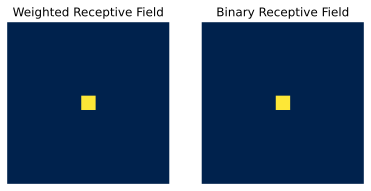

In [11]:
field = torch.zeros(1, 1, 11, 11)
field.requires_grad = True

plot_receptive_field(field, field)

### Visualize the Horizontal Receptive Field

<Figure size 800x800 with 0 Axes>

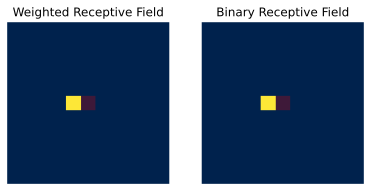

In [12]:
hconv = CausalConvolutionHStack(1, 1, kernel_size=3, mask_center=True)
hconv.conv.weight.data.fill_(1.0)
hconv.conv.bias.data.fill_(0.0)
hfield = hconv(field)
plot_receptive_field(field, hfield)

### Visualize the Vertical Receptive Field

<Figure size 800x800 with 0 Axes>

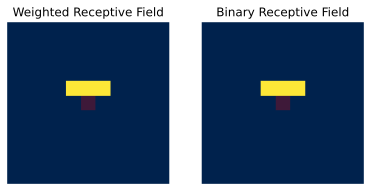

In [13]:
vconv = CausalConvolutionVStack(1, 1, kernel_size=3, mask_center=True)
vconv.conv.weight.data.fill_(1.0)
vconv.conv.bias.data.fill_(0.0)
vfield = vconv(field)
plot_receptive_field(field, vfield)

### Combine the Horizontal and Vertical Receptive Fields

<Figure size 800x800 with 0 Axes>

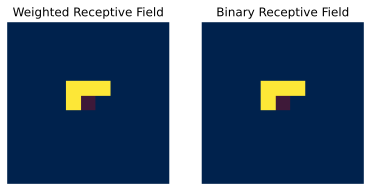

In [14]:
combined = hfield + vfield
plot_receptive_field(field, combined)

### Stacking Multiple Layers

Note that the center should be masked for the first layer to ensure causality but not for the subsequent layers.

Layer 2


<Figure size 800x800 with 0 Axes>

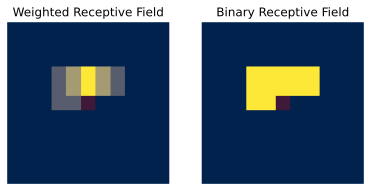

Layer 3


<Figure size 800x800 with 0 Axes>

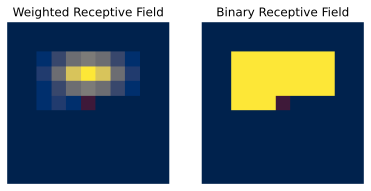

Layer 4


<Figure size 800x800 with 0 Axes>

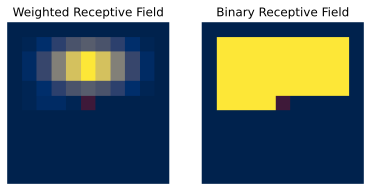

Layer 5


<Figure size 800x800 with 0 Axes>

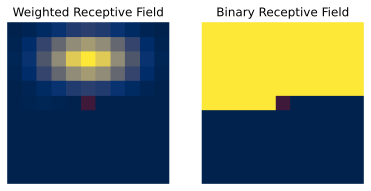

In [15]:
hconv_subsequent = CausalConvolutionHStack(1, 1, kernel_size=3, mask_center=False)
hconv_subsequent.conv.weight.data.fill_(1.0)
hconv_subsequent.conv.bias.data.fill_(0.0)
vconv_subsequent = CausalConvolutionVStack(1, 1, kernel_size=3, mask_center=False)
vconv_subsequent.conv.weight.data.fill_(1.0)
vconv_subsequent.conv.bias.data.fill_(0.0)

for layer_idx in range(4):
    vfield = vconv_subsequent(vfield)
    hfield = hconv_subsequent(hfield)
    combined = hfield + vfield
    print(f"Layer {layer_idx+2}")
    plot_receptive_field(field, combined)

We can also check the vertical ones.

<Figure size 800x800 with 0 Axes>

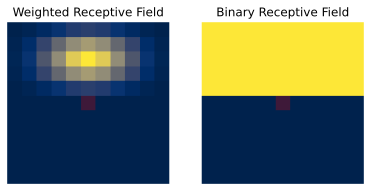

In [16]:
plot_receptive_field(field, vfield)

In [17]:
# clean up the computational graph
del field, hconv, vconv, hconv_subsequent, vconv_subsequent

## (Gated) PixelCNN

PixelCNN uses gated convolutions to perform the causal modeling.

![Gated Convolution](./PixelCNN_GatedConv.svg)

In the figure above,the path on the left is the vertical stack and the path on the right is the horizontal stack. The vertical stack is used to model the vertical dependencies, while the horizontal stack is used to model the horizontal dependencies. The gated convolution is used to model the dependencies between the two stacks. The gated activation unit can be computed as follows:
$$\boldsymbol{y} = \tanh(\boldsymbol{W}_f \boldsymbol{x}) \odot \sigma(\boldsymbol{W}_g \boldsymbol{z})$$
Also we use residual connections on the horizontal stack to as we are using horizontal stack as the output.

In [18]:
class GatedMasedCausalConvolution(nn.Module):
    def __init__(self, in_channels, **kwargs):
        super().__init__()
        self.vconv = CausalConvolutionVStack(in_channels, 2 * in_channels, **kwargs)
        self.hconv = CausalConvolutionHStack(in_channels, 2 * in_channels, **kwargs)
        self.v2h = nn.Conv2d(2 * in_channels, 2 * in_channels, 1, padding=0)
        self.hconv_1x1 = nn.Conv2d(in_channels, in_channels, 1, padding=0)

    def forward(self, vstack, hstack):
        # vertical stack computation on the left
        vstack_features = self.vconv(vstack)
        vstack_val, vstack_gate = vstack_features.chunk(2, dim=1)
        vstack_out = torch.tanh(vstack_val) * torch.sigmoid(vstack_gate)  # element-wise multiplication

        # horizontal stack computation on the right
        hstack_features = self.hconv(hstack)
        # use horizontal stack as output
        hstack_features = hstack_features + self.v2h(vstack_features)
        hstack_val, hstack_gate = hstack_features.chunk(2, dim=1)
        hstack_features = torch.tanh(hstack_val) * torch.sigmoid(hstack_gate)
        hstack_out = self.hconv_1x1(hstack_features)
        hstack_out = hstack_out + hstack  # residual connection

        return vstack_out, hstack_out

## PixelCNN Model

### Inference

In [104]:
from models.pixelcnn import PixelCNN

inference_model = PixelCNN(in_channels=1, num_hiddens=64)
input_img = torch.zeros(1, 1, 32, 32)
input_img.requires_grad = True
output = inference_model(input_img)

<Figure size 800x800 with 0 Axes>

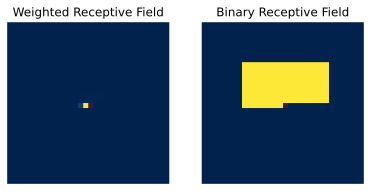

In [105]:
plot_receptive_field(input_img, output.squeeze(dim=2))

In [95]:
del inference_model, input_img, output

## Generation

In [106]:
model = PixelCNN.load_from_checkpoint('tensorboard_logs/pixelcnn_v1/version_8/checkpoints/epoch=98-step=170181.ckpt')

In [107]:
model.eval()

PixelCNN(
  (vconv): CausalConvolutionVStack(
    (conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (hconv): CausalConvolutionHStack(
    (conv): Conv2d(1, 64, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
  )
  (gated_convs): ModuleList(
    (0-6): 7 x GatedMaskedCausalConvolution(
      (vconv): CausalConvolutionVStack(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (hconv): CausalConvolutionHStack(
        (conv): Conv2d(64, 128, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
      )
      (v2h): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (hconv_1x1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (conv_out): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
)